Fuente: https://github.com/habla-liaa/encodecmae?tab=readme-ov-file

###🚀 We recommend using a runtime with GPU to run this notebook

In [ ]:
!pip uninstall encodecmae -y
!rm -r encodecmae
!git clone https://github.com/habla-liaa/encodecmae.git
%cd encodecmae
%pip install -e .
%cd ..

rm: cannot remove 'encodecmae': No such file or directory
Cloning into 'encodecmae'...
remote: Enumerating objects: 273, done.
remote: Counting objects: 100% (273/273), done.
remote: Compressing objects: 100% (193/193), done.
remote: Total 273 (delta 133), reused 154 (delta 58), pack-reused 0 (from 0)
Receiving objects: 100% (273/273), 69.56 KiB | 9.94 MiB/s, done.
Resolving deltas: 100% (133/133), done.
/content/encodecmae
Obtaining file:///content/encodecmae
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 91.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.

In [ ]:
# @title 1) Install EnCodecMAE and download Google Speech Commands
!git clone https://github.com/habla-liaa/encodecmae.git
%cd encodecmae
%pip install -e .
%cd ..
!wget http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz
!mkdir gsc
!tar xzf speech_commands_v0.02.tar.gz -C gsc

fatal: destination path 'encodecmae' already exists and is not an empty directory.
/content/encodecmae
Obtaining file:///content/encodecmae
  Preparing metadata (setup.py) ... done
  Attempting uninstall: encodecmae
    Found existing installation: encodecmae 0.0.1
    Uninstalling encodecmae-0.0.1:
      Successfully uninstalled encodecmae-0.0.1
  Running setup.py develop for encodecmae
/content
--2025-06-18 01:19:02--  http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 172.253.118.207, 172.217.194.207, 142.251.10.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|172.253.118.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2428923189 (2.3G) [application/gzip]
Saving to: ‘speech_commands_v0.02.tar.gz’

speech_commands_v0. 100%[===================>]   2.26G  22.2MB/s    in 1m 45s  

2025-06-18 01:20:48 (22.1 MB/s) - ‘speech_commands_v0.02.tar.gz’ saved [2428923

### 2) ⚠️ Before running the next cell, restart the runtime.

Let's load the Mel256 to EC base model

In [ ]:
from encodecmae import load_model
import torch

num_gpus = torch.cuda.device_count()
if num_gpus>0:
  device='cuda:0'
else:
  device='cpu'
model = load_model('mel256-ec-base_st', device=device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gin/config.py:615: FutureWarning: `nn.Container` is deprecated. All of it's functionality is now implemented in `nn.Module`. Subclass that instead.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
/usr/local/lib/python3.11/dist-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss f

We can check the available models by running the **get_available_models** function

In [ ]:
from encodecmae.hub import get_available_models

get_available_models()

['ec-ec-base',
 'ec-ec-base_st',
 'ec-ec-large',
 'ec-ec-large_st',
 'ec-ec-small',
 'mel128-ec-base',
 'mel256-ec-base-as',
 'mel256-ec-base-fma',
 'mel256-ec-base-ll',
 'mel256-ec-base',
 'mel256-ec-base_st-as',
 'mel256-ec-base_st-fma',
 'mel256-ec-base_st-ll',
 'mel256-ec-base_st',
 'mel256-ec-large-as',
 'mel256-ec-large',
 'mel256-ec-large_st-as',
 'mel256-ec-large_st',
 'mel256-ec-small']

### 3) Extract features from an audio file
This will automatically load the wav, resample it to the right sampling rate, and extract features returning them as numpy arrays. Another option is to use the method extract_features_from_array(x), if the audio is already loaded in a numpy array.

The resulting features will be sequences with a rate of 75 Hz and a dimensionality of 768 for small and base models, and 1024 for large models.

In [ ]:
features = model.extract_features_from_file('blues.00000.wav')

In [ ]:
features.shape

(2250, 768)

By default the above function will extract features from the last layer of the transformer encoder. You can choose any other layer or return all at the same time:

In [ ]:
features = model.extract_features_from_file('blues.00000.wav', layer='all')
print(features.shape)
features = model.extract_features_from_file('blues.00000.wav', layer=9)
print(features.shape)

(10, 2250, 768)
(2250, 768)


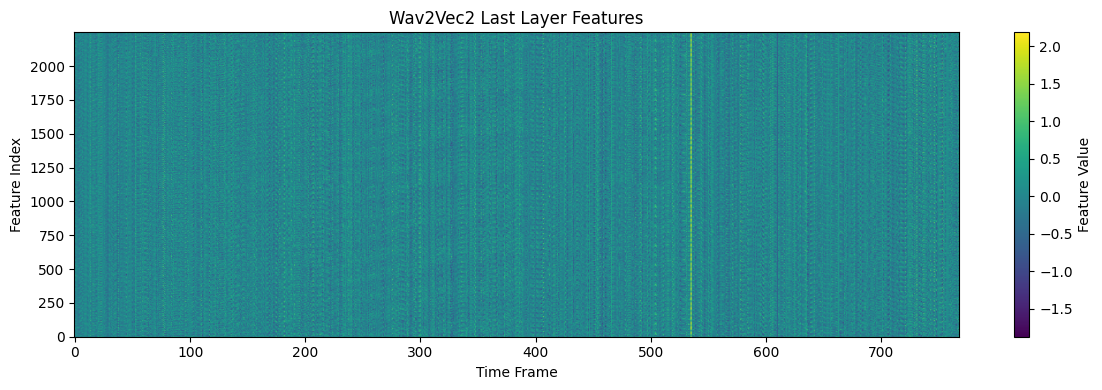

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.imshow(features, aspect='auto', origin='lower')
plt.colorbar(label='Feature Value')
plt.xlabel('Time Frame')
plt.ylabel('Feature Index')
plt.title('Wav2Vec2 Last Layer Features')
plt.tight_layout()
plt.show()

In [ ]:
import kagglehub
andradaolteanu_gtzan_dataset_music_genre_classification_path = kagglehub.dataset_download('andradaolteanu/gtzan-dataset-music-genre-classification')

print('Data source import complete.')

Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
# /kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv
/kaggle/input/gtzan-dataset-music-genre-classification/Data/features_30_sec.csv
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00005.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00057.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00020.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00072.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00040.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00043.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00010.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco/disco00071.png
/kaggle/input/gtzan-dataset-music-genre-classification/Data/image

In [ ]:
from sklearn.model_selection import train_test_split
import soundfile as sf

# Funciones auxiliares
def train_test_split_path():
    '''
    Division fija de los datos de entrenamiento y testeo para todos los experimentos
    '''
    X_path = []
    y = []
    genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
    for id, genre in enumerate(genres):
        for i in range(100):
            if not (i == 54 and genre == 'jazz'):
                path = f'/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/{genre}/{genre}.000{i:02}.wav'
                X_path.append(path)
                y.append(id)
    X_train_path, X_eval_path, y_train, y_eval = train_test_split(X_path, y, test_size=0.1, random_state=28, stratify=y)
    X_train_path, X_test_path, y_train, y_test = train_test_split(X_train_path, y_train, test_size=0.2, random_state=28, stratify=y_train)
    return X_train_path, X_test_path, X_eval_path, y_train, y_test, y_eval


In [ ]:
def get_features_EnCodecMAE(paths, sr, max_len, hop_length, win_length):
    X = []
    for path in paths:
        x, fs = librosa.load(path, sr=model.wav_encoder.fs)
        X.append(model.extract_features_from_array(x[:max_len]))
    return X

In [ ]:
import librosa

X_train_path, X_test_path, X_eval_path, y_train, y_test, y_eval = train_test_split_path()

MAX_LEN = 660000//2
SR = 22050
HOP_LENGTH = int(SR * 0.01)  # 10 ms hop length
WIN_LENGTH = int(SR * 0.025)  # 30 ms window length
feature_name = 'EnCodecMAE'

for paths, name in zip([X_train_path, X_test_path, X_eval_path], ['X_train', 'X_test', 'X_eval']):
    X = get_features_EnCodecMAE(paths, sr=SR, max_len=MAX_LEN, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    np.save(f'{name}_{feature_name}.npy', X)

    print(f"Guardado {name} con {feature_name} en ../Data/{name}_{feature_name}.npy")
    print(f"Elementos:", len(X))
    print(f"Primer elemento:", X[0].shape)
    print('-' * 50)

Guardado X_train con EnCodecMAE en ../Data/X_train_EnCodecMAE.npy
Elementos: 719
Primer elemento: (1, 1031, 768)
--------------------------------------------------
Guardado X_test con EnCodecMAE en ../Data/X_test_EnCodecMAE.npy
Elementos: 180
Primer elemento: (1, 1031, 768)
--------------------------------------------------
Guardado X_eval con EnCodecMAE en ../Data/X_eval_EnCodecMAE.npy
Elementos: 100
Primer elemento: (1, 1031, 768)
--------------------------------------------------
